In [ ]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

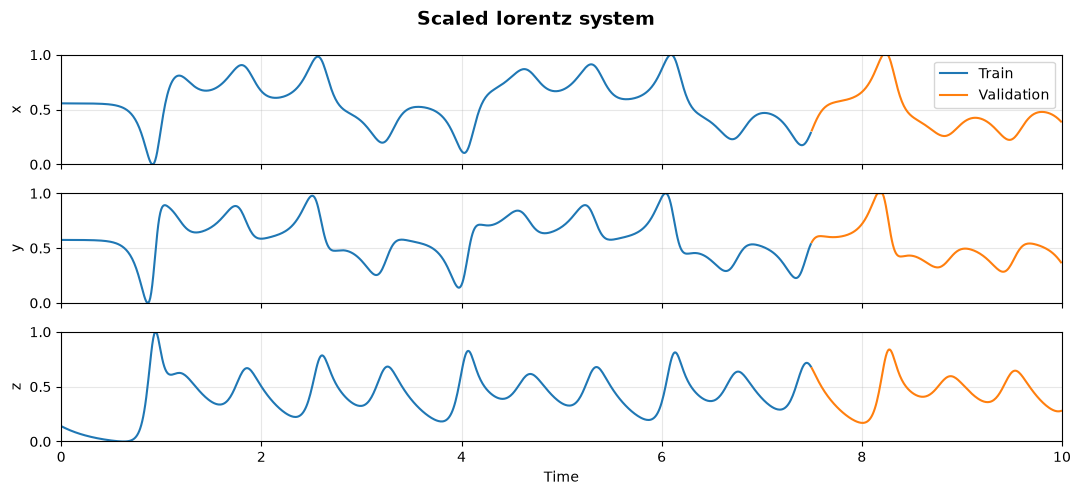

In [3]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Dense embedding

Instead of using standard $R_y$ encoding, in this section we employ a dense embedding, which allows all three channels to be embedded in one qubit:

$$
|X_{t,1},X_{t,2},X_{t,3}\rangle = R_z (\pi X_{t,3}) R_y (\pi X_{t,2}) R_z(\pi X_{t,1}) |+\rangle
$$

We consider two variants for the output stage:

- Using a single qubit and assigning each channel to the expectation value of one of the Pauli operators $[\langle X \rangle, \langle Y \rangle, \langle Z \rangle]$.
- Measuring the Pauli-Z operator on three different qubits, each corresponding to one channel.

In the first variant the outputs are very coupled since they come from the same qubit. The second variant overcomes this limitation with the cost of higher number of qubits needed.